In [77]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [78]:
input_ventas = "../data/processed/tabla_principal_ventas.csv"
input_events = "../data/processed/events_clean.csv"
output_segmentacion = "../data/processed/"

In [79]:
df_v = pd.read_csv(input_ventas)
df_e = pd.read_csv(input_events)

for col in ['created_at', 'shipped_at', 'delivered_at']:
    df_v[col] = pd.to_datetime(df_v[col])

In [80]:
# Cálculo del tiempo de envío 
df_v['tiempo_envio_total'] = (df_v['delivered_at'] - df_v['shipped_at']).dt.days

# Definimos el "hoy" del dataset para la recencia
hoy = df_v['created_at'].max() + dt.timedelta(days=1)

# Agrupamos por usuario
perfil_compra = df_v.groupby('user_id').agg({
    'created_at': lambda x: (hoy - x.max()).days, # recencia
    'order_id': 'nunique',                        # frecuencia
    'revenue': 'sum',                             # monetario
    'is_returned': 'mean',                        # tasa de retorno (calidad)
    'tiempo_envio_total': 'mean'                  # media de envío (logística)
}).reset_index()

perfil_compra.columns = ['user_id', 'recencia', 'frecuencia', 'monetario', 'tasa_retorno', 'media_envio']
perfil_compra.head()

,user_id,recencia,frecuencia,monetario,tasa_retorno,media_envio
0,1,551,1,159.990000,0.0,NaN
1,2,701,1,22.000000,0.0,1.0
2,3,167,4,402.200001,0.0,1.0
3,4,461,1,148.000000,0.0,1.0
4,5,455,1,65.650000,0.0,NaN


In [81]:
perfil_web = df_e.groupby('user_id').agg({
    'session_id': 'nunique',
    'event_type': [
        lambda x: (x == 'product').sum(), # vistas de productos
        lambda x: (x == 'cart').sum()     # productos en carrito
    ]
}).reset_index()

perfil_web.columns = ['user_id', 'web_visitas', 'web_productos', 'web_carrito']
perfil_web.head()

,user_id,web_visitas,web_productos,web_carrito
0,1.0,3,9,9
1,2.0,1,1,1
2,3.0,5,7,7
3,4.0,1,1,1
4,5.0,3,9,9


In [82]:
# Unimos la información de compras con la de navegación web
tabla_clientes = perfil_compra.merge(perfil_web, on='user_id', how='left').fillna(0)

# Definimos las métricas finales que definen el perfil del usuario
features = [
    'recencia', 'frecuencia', 'monetario', 'tasa_retorno', 
    'media_envio', 'web_visitas', 'web_productos', 'web_carrito'
]

# Normalización de los datos 
scaler = StandardScaler()
tabla_escalada = scaler.fit_transform(tabla_clientes[features])

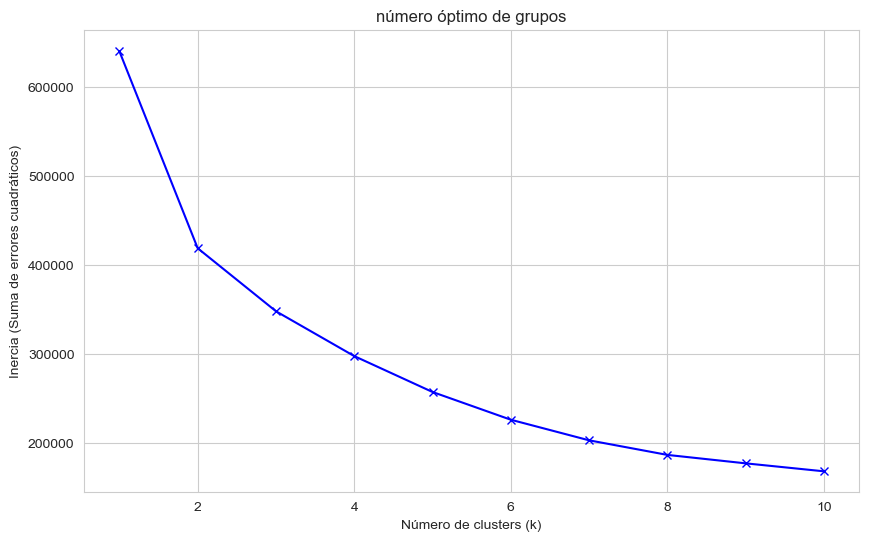

In [83]:
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(tabla_escalada)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.title('número óptimo de grupos')
plt.show()

In [84]:
# Aplicamos el algoritmo para crear 5 grupos de comportamiento
modelo_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
tabla_clientes['Cluster'] = modelo_kmeans.fit_predict(tabla_escalada)

In [85]:
output_segmentacion = "../data/processed/segmentacion_clientes.csv"

In [86]:
tabla_clientes.to_csv(output_segmentacion, index=False)

In [87]:
# Calculamos la media de cada métrica para cada uno de los 5 clusters
resumen_segmentos = tabla_clientes.groupby('Cluster')[features].mean()

# Añadimos el conteo de cuántos clientes hay en cada grupo
resumen_segmentos['n_clientes'] = tabla_clientes.groupby('Cluster')['user_id'].count()

# Mostramos el resultado ordenado para facilitar la lectura
resumen_segmentos = resumen_segmentos.sort_values(by='monetario', ascending=False)
resumen_segmentos

,recencia,frecuencia,monetario,tasa_retorno,media_envio,web_visitas,web_productos,web_carrito,n_clientes
Cluster,,,,,,,,,
1,315.369648,2.327699,347.454991,0.088744,1.156151,5.571993,17.216903,17.216903,8105
4,229.561407,2.583483,232.620945,0.066730,1.405132,3.610745,6.003192,6.003192,15039
3,401.010762,1.311526,94.969938,0.871731,2.103295,1.668932,2.556500,2.556500,7062
2,970.730051,1.125402,80.760830,0.003328,0.622934,1.432342,2.129368,2.129368,14625
0,218.996677,1.186664,75.563144,0.002868,0.569070,1.407492,1.890949,1.890949,35213


In [88]:
# Mapeo de nombres
nombres_segmentos = {
    1: 'VIP',
    4: 'Recurrentes',
    3: 'Problemáticos',
    2: 'Inactivos',
    0: 'Nuevos / Esporádicos'
}

In [89]:
tabla_clientes['segmento_nombre'] = tabla_clientes['Cluster'].map(nombres_segmentos)

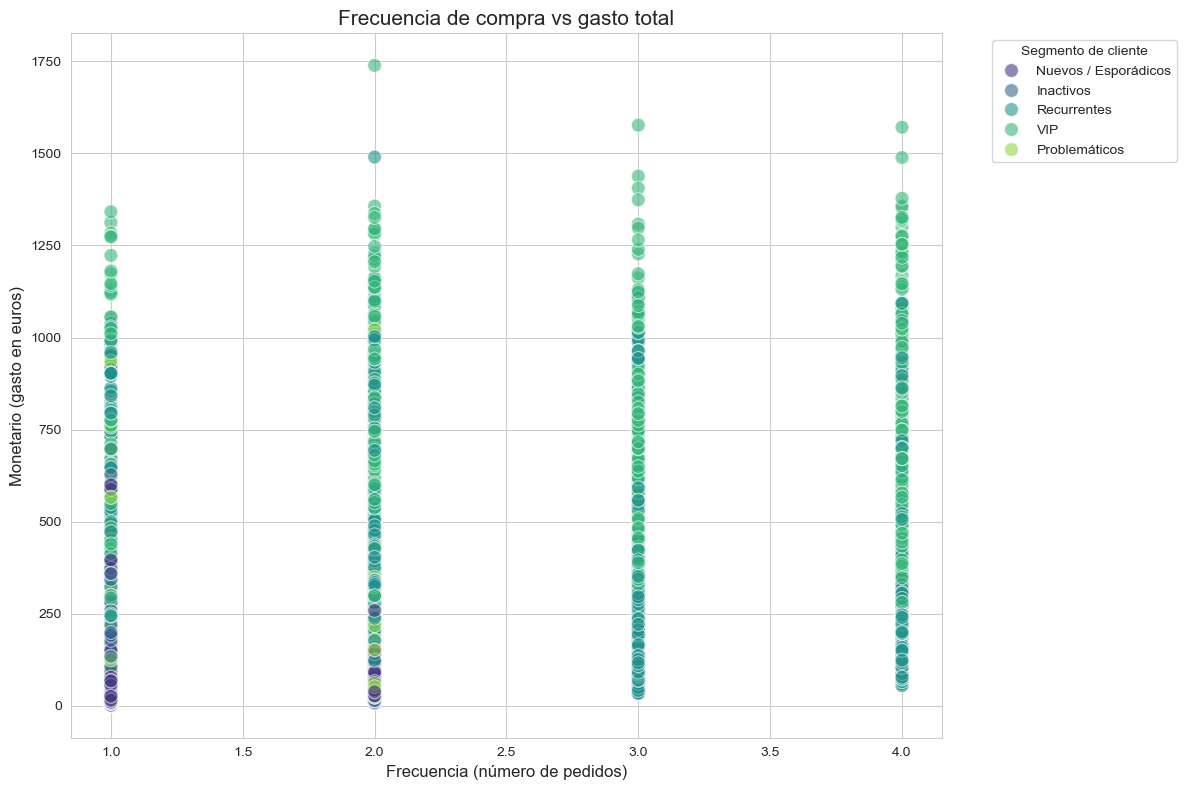

In [90]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.scatterplot(
    x='frecuencia', 
    y='monetario', 
    hue='segmento_nombre', 
    data=tabla_clientes, 
    palette='viridis', 
    s=100, 
    alpha=0.6
)

plt.title('Frecuencia de compra vs gasto total', fontsize=15)
plt.xlabel('Frecuencia (número de pedidos)', fontsize=12)
plt.ylabel('Monetario (gasto en euros)', fontsize=12)
plt.legend(title='Segmento de cliente', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

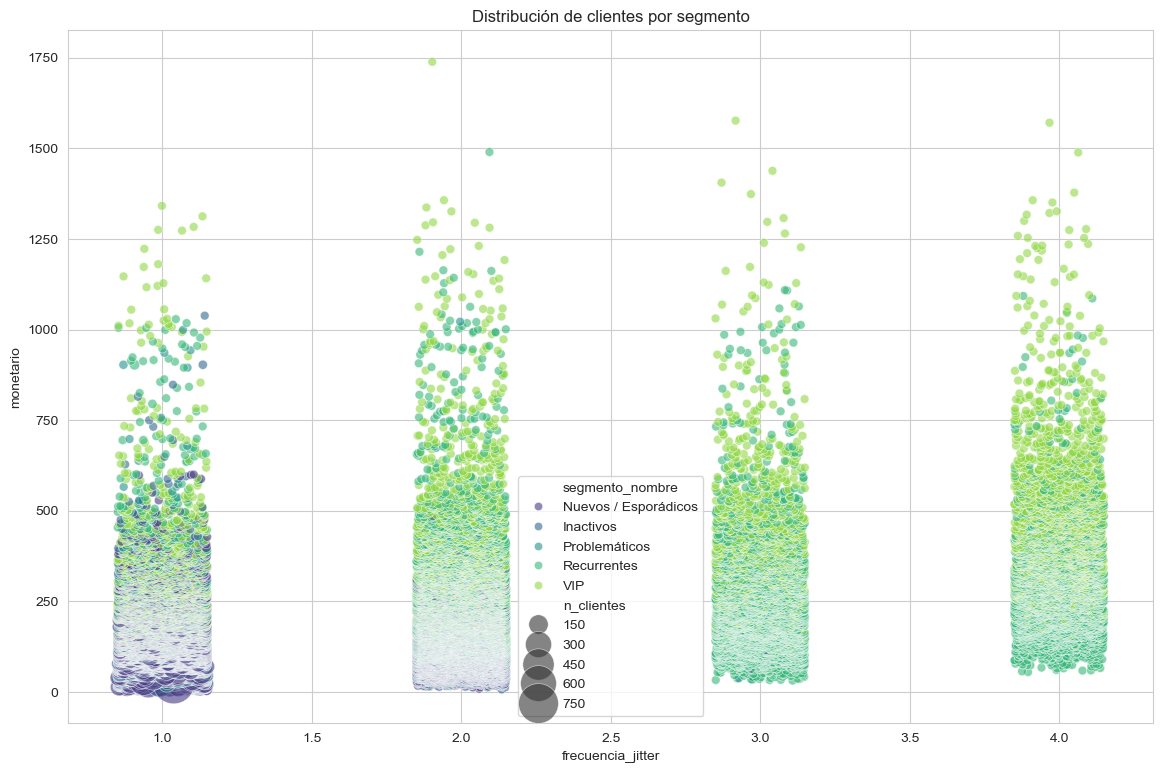

In [91]:
df_burbujas = tabla_clientes.groupby(['frecuencia', 'monetario', 'segmento_nombre']).size().reset_index(name='n_clientes')

# Añadimos un "jitter" a la frecuencia para separar las burbujas
df_burbujas['frecuencia_jitter'] = df_burbujas['frecuencia'] + np.random.uniform(-0.15, 0.15, size=len(df_burbujas))

plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

sns.scatterplot(
    data=df_burbujas,
    x='frecuencia_jitter',
    y='monetario',
    hue='segmento_nombre',
    size='n_clientes',
    sizes=(40, 900),
    palette='viridis',
    alpha=0.6
)

plt.title('Distribución de clientes por segmento')
plt.show()

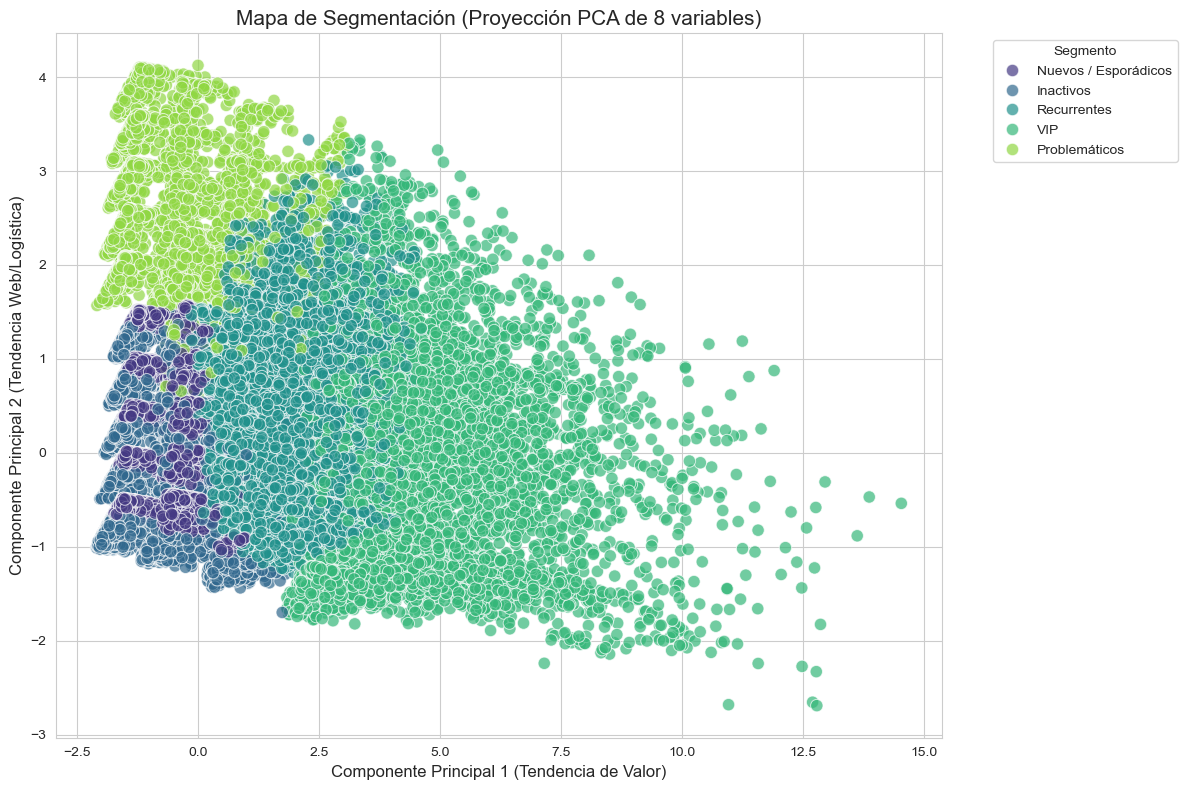

In [92]:
# 1. Reducción de las 8 variables a 2 dimensiones (PCA)
pca = PCA(n_components=2)
componentes = pca.fit_transform(tabla_escalada)

# 2. Creamos un DataFrame para la visualización
df_visualizacion = pd.DataFrame(data=componentes, columns=['Eje_1', 'Eje_2'])
df_visualizacion['Segmento'] = tabla_clientes['segmento_nombre']

# 3. Mapa de clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Eje_1', 
    y='Eje_2', 
    hue='Segmento', 
    data=df_visualizacion, 
    palette='viridis', 
    s=80, 
    alpha=0.7
)

plt.title('Mapa de Segmentación (Proyección PCA de 8 variables)', fontsize=15)
plt.xlabel('Componente Principal 1 (Tendencia de Valor)', fontsize=12)
plt.ylabel('Componente Principal 2 (Tendencia Web/Logística)', fontsize=12)
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [93]:
print(tabla_clientes.groupby('segmento_nombre')[['frecuencia', 'monetario', 'tasa_retorno']].mean())

                      frecuencia   monetario  tasa_retorno
segmento_nombre                                           
Inactivos               1.125402   80.760830      0.003328
Nuevos / Esporádicos    1.186664   75.563144      0.002868
Problemáticos           1.311526   94.969938      0.871731
Recurrentes             2.583483  232.620945      0.066730
VIP                     2.327699  347.454991      0.088744


In [94]:
print(tabla_clientes['segmento_nombre'].value_counts())

segmento_nombre
Nuevos / Esporádicos    35213
Recurrentes             15039
Inactivos               14625
VIP                      8105
Problemáticos            7062
Name: count, dtype: int64


In [95]:
tabla_clientes.to_csv("../data/processed/segmentacion_clientes_final.csv", index=False)